In [1]:
import pointCollection as pc
import numpy as np
import glob
import re
import pandas as pd
import argparse
import matplotlib.pyplot as plt
import os
%load_ext autoreload
%autoreload 2

In [2]:
from ATL06_xovers import collect_xovers

In [3]:
import ATL06_xovers as A6x
dir(A6x)

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'collect_xovers',
 'filter_xovers',
 'read_xovers',
 'xover_slope']

# Crossover save format:

The routines that produce crossovers store them in 100x100-km tiles, with one directory of tiles for each cycle. Each tile contains two groups and some metadata; the data_0 and data_1 groups store data from the early and late tracks in each crossover, respectively.  The datasets in these groups are Nx2, where N is the number of crossovers.  Each row in these datasets represents the two measurements that surround the crossover point, and the W dataset specifies how to interpolate between these to measurements to calculate the exact crossover value.  

The collect_xovers routine reads a set of tile files, combines the crossovers from these tiles, and returns three data structures: 'v' contains the interpolated values from the two tracks for each crossover, and the other two data structures contain the raw (uninterpolated) values.  In this notebook we use the 'v' structure to check for RGTs that have unusually large residuals compared to all the other tracks.

In [4]:
thedir='/discover/nobackup/besmith4/ATL06_xovers/rel007/Antarctic'

## read all the data from one cycle
This takes a few minutes, and can lead to a crash if the server does not have enough memory.  The 4-core instance is usually enough.


In [5]:
cycle='28'
v, D0, D1 = collect_xovers(os.path.join(thedir, f'cycle_{cycle}','E*_N*.h5'), max_delta_t = 24*3600*5)
print(v.summary())

                 field 	shape 	n_finite 	STD 	 minmax
                     x 	(3556854, 2)	7113708	2.69e+05	-9.48e+05 9.48e+05
                     y 	(3556854, 2)	7113708	2.60e+05	-8.50e+05 9.49e+05
            delta_time 	(3556854, 2)	7113708	2.20e+06	2.35e+08 2.43e+08
                  h_li 	(3556854, 2)	7113708	4.86e+02	4.97e-02 4.10e+03
            h_li_sigma 	(3556854, 2)	7113708	3.71e-02	6.17e-03 1.00e+00
                h_mean 	(3556854, 2)	7113708	4.86e+02	4.91e-02 4.10e+03
                  spot 	(3556854, 2)	7113708	1.71e+00	1.00e+00 6.00e+00
                   rgt 	(3556854, 2)	7113708	3.89e+02	1.00e+00 1.39e+03
             dh_fit_dx 	(3556854, 2)	7113708	7.77e-03	-2.50e-01 2.50e-01
             dh_fit_dy 	(3556854, 2)	7113708	6.88e-03	-2.49e-01 2.50e-01
 atl06_quality_summary 	(3556854, 2)	7113708	2.00e-05	0.00e+00 9.86e-03
              latitude 	(3556854, 2)	7113708	1.44e+00	-8.84e+01 -8.12e+01
           seg_azimuth 	(3556854, 2)	7113708	4.43e+01	-1.66e+02 -1.36e+01
  

# compute per-track statistics

The statistics we'll look at compare h_li from each track against h_li from all the other tracks.
The 'v' array contains the measurements from the two tracks, with the earlier measurement in the first column and the later measurement in the second column.  Since a track can be found in either column, to get a consistent set of differences, for each track T we'll combine the height differences from crossovers with T in the first column with the negative of the height differences from crossovers with T in the second column.'

We'll compute a three-sigma edit on the crossovers from each track to eliminate outliers.

In [13]:
def track_stats(dh, rgt, sigma_min=0.03):
    keep = np.ones_like(dh, dtype=bool)
    for count in range(3):
        sigma = pc.RDE(dh[keep])
        keep = np.abs(dh-np.nanmedian(dh[keep])) < 3*np.maximum(sigma, sigma_min)
    dh=dh[keep]
    return {
        'rgt':rgt,
        'sigma_hat':pc.RDE(dh),
        'med':np.nanmedian(dh),
        'bar':np.nanmean(dh),
        'N':np.sum(np.isfinite(dh))}

In [14]:
_, rdict0 = pc.unique_by_rows(v.rgt[:,0], return_dict=True)
_, rdict1 = pc.unique_by_rows(v.rgt[:,1], return_dict=True)
stats=[]
sigma_min=0.05
for track, ind0 in rdict0.items():
    dh = np.diff(v.h_li[ind0,:], axis=1).ravel()
    if track in rdict1:
        dh = np.concatenate([dh, -np.diff(v.h_li[rdict1[track],:]).ravel()])
    stats.append(
        track_stats(dh, track[0]))

for track, ind1 in rdict1.items():
    if track in rdict0:
        continue   
    dh = -np.diff(v.h_li[ind0,:], axis=1).ravel()
    stats.append(
        track_stats(dh, track[0]))
df = pd.DataFrame(stats)

# Track statistics:

Text(0.5, 0, 'number of crossovers per rgt')

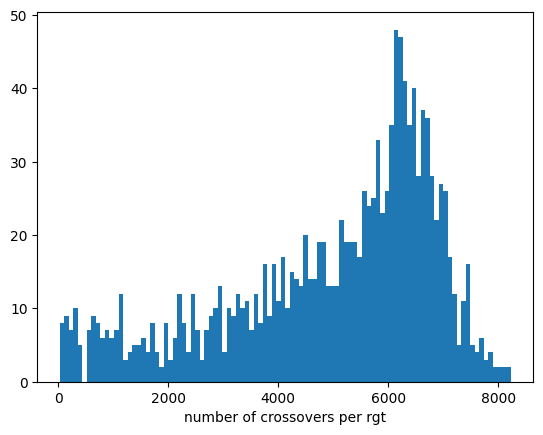

In [15]:
plt.figure()
plt.hist(df.N, 100);
plt.gca().set_xlabel('number of crossovers per rgt')

In [16]:
# filter out rgts that have fewer than 1000 xovers

In [17]:
df = df[df['N'] >1000].reset_index(drop=True)

Text(0.5, 0, 'per-track spread(dh), m')

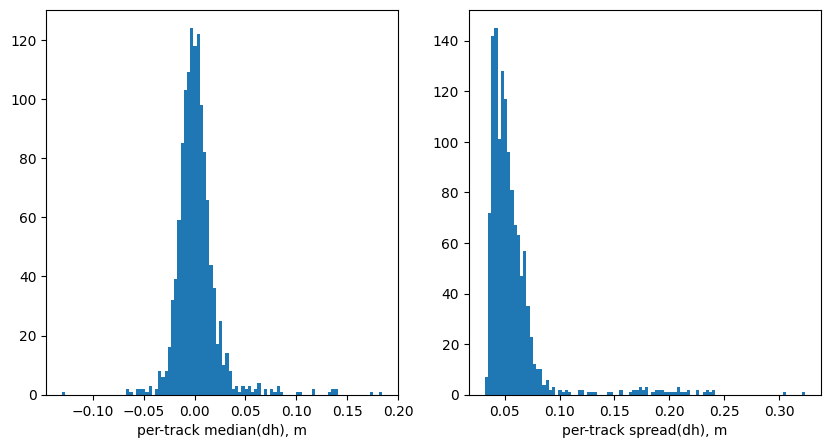

In [18]:
hf, hax=plt.subplots(1, 2, figsize=[10,5])
plt.sca(hax[0])
plt.hist(df['med'], 100);
plt.gca().set_xlabel('per-track median(dh), m')
plt.sca(hax[1])
plt.hist(df['sigma_hat'], 100);
plt.gca().set_xlabel('per-track spread(dh), m')

## plot median vs. spread:

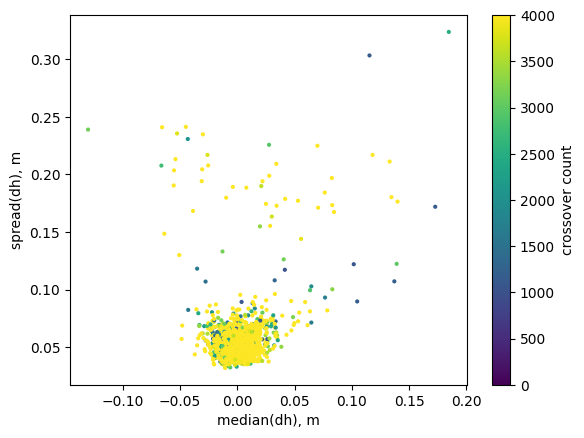

In [19]:
hs = plt.scatter(df['med'], df['sigma_hat'],4, c=df['N'], clim=[0, 4000])
plt.gca().set_xlabel('median(dh), m')
plt.gca().set_ylabel('spread(dh), m')
plt.colorbar(hs, label='crossover count')

# outlier RGTs:

In [20]:
bads = np.array((np.abs(df['med']) > 0.05) | (df['sigma_hat'] > 0.15))
np.array(df.rgt)[np.flatnonzero(bads)]

array([   4,   32,   57,   84,   99,  101,  102,  117,  142,  159,  178,
        186,  205,  218,  236,  239,  255,  261,  280,  304,  315,  328,
        354,  388,  466,  481,  482,  496,  497,  498,  499,  503,  509,
        521,  557,  574,  583,  606,  617,  646,  651,  652,  653,  657,
        685,  697,  708,  722,  757,  767,  780,  802,  812,  829,  849,
        971, 1108, 1109, 1150, 1151, 1152])

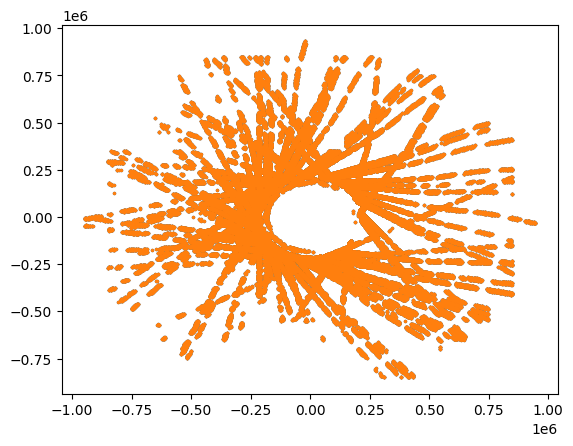

In [21]:
bad_rgts = np.array(df.rgt)[np.flatnonzero(bads)]

plt.figure()
these = np.flatnonzero(np.any(np.isin(v.rgt, bad_rgts), axis=1))
plt.plot(v.x[these,:], v.y[these,:],'.', markersize=3)

# worst track, by spread:

In [22]:
worst = df.rgt[np.argmax(df.sigma_hat)]

In [23]:
worst

np.int64(497)

In [24]:
# the worst rgt in cycle 28 is 497.  We can look for it on css: (this takes a minute)
! ls /css/icesat-2/ATLAS/ATL06.007/*/*04972811*

/css/icesat-2/ATLAS/ATL06.007/2025.07.18/ATL06_20250718074758_04972811_007_01.h5


# plots of that worst RGT:

In [25]:
D=pc.ATL06.data(beam_pair=2).from_h5('/css/icesat-2/ATLAS/ATL06.007/2025.07.18/ATL06_20250718074758_04972811_007_01.h5')
D.get_xy(3031)

<class 'pointCollection.ATL06.data.data'> with shape (108997, 2),
with fields:
['delta_time', 'h_li', 'h_li_sigma', 'latitude', 'longitude', 'atl06_quality_summary', 'segment_id', 'sigma_geo_h', 'x_atc', 'y_atc', 'seg_azimuth', 'sigma_geo_at', 'sigma_geo_xt', 'dh_fit_dx', 'dh_fit_dx_sigma', 'h_mean', 'dh_fit_dy', 'h_rms_misfit', 'h_robust_sprd', 'n_fit_photons', 'signal_selection_source', 'snr_significance', 'w_surface_window_final', 'bsnow_conf', 'bsnow_h', 'cloud_flg_asr', 'cloud_flg_atm', 'r_eff', 'tide_ocean', 'valid', 'BP', 'LR', 'cycle_number', 'rgt', 'x', 'y']

Text(0, 0.5, 'h_li, m')

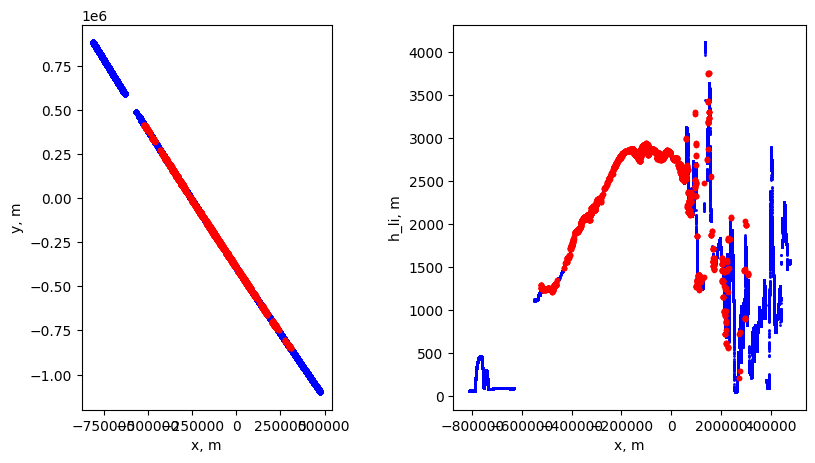

In [26]:
hf, hax=plt.subplots(1, 2, figsize=[10,5])
plt.sca(hax[0])
plt.plot(D.x, D.y,'b.', label='all ATL06 points')
these = np.any(v.rgt==worst, axis=1)
plt.plot(v.x[these], v.y[these],'r.', label='crossover points')
plt.gca().set_aspect(1)
plt.gca().set_xlabel('x, m')
plt.gca().set_ylabel('y, m')

plt.sca(hax[1])
D.h_li[D.atl06_quality_summary>0]=np.nan
plt.plot(D.x, D.h_li,'b.', markersize=2)
these = np.any(v.rgt==worst, axis=1)
plt.plot(v.x[these], v.h_li[these],'r.')
plt.gca().set_xlabel('x, m')
plt.gca().set_ylabel('h_li, m')


In the case of cycle 28, the worst RGT is one that happens to hit the transiantarctic mountains.
